In [1]:
import numpy as np
# from patchsim.src.patchsim.core import model
# !pip install ipympl
import matplotlib.pyplot as plt
import pandas as pd

In [2]:
weibull_shape = 3.7
weibull_scale = 120

age_stratification = [i*5 for i in range(80//5)]


In [3]:
age_dist_project = pd.read_csv("age_dist_projected_karnataka.csv")
age_dist_project.head()
total_pop_project = (age_dist_project['Population'][age_dist_project['Age group'] == 'Total']).iloc[0]
age_dist_project['Fraction'] = age_dist_project['Population']/66845
print(total_pop_project)
age_dist_project = age_dist_project.drop(index=17)

66845


(17,)
(16,)


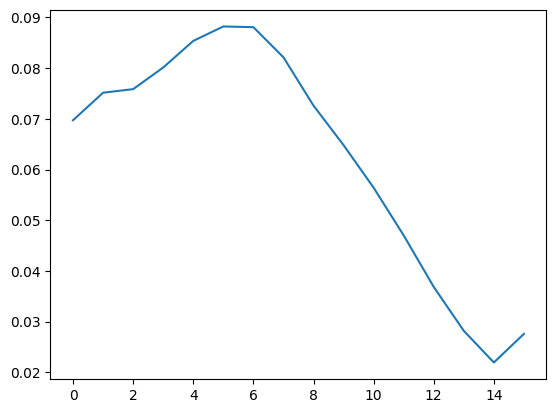

In [4]:
fraction_population = np.copy(age_dist_project['Fraction'].to_numpy())
print(fraction_population.shape)
last_frac = fraction_population[-1]
fraction_population = fraction_population[:-1]
print(fraction_population.shape)
fraction_population[-1]=last_frac+fraction_population[-1]
plt.plot(fraction_population)

In [5]:
casesfile = "IRDD_allka.csv"
casesframe = pd.read_csv(casesfile)
districts = casesframe['District'].unique()
print(age_stratification)
# agegroups_min = np.array((0, 15, 65 ))
print(casesframe.head(500))
print(casesframe[casesframe['District']=='Bagalakote'])

print(f'Number of distrcits: {len(districts)}')


[0, 5, 10, 15, 20, 25, 30, 35, 40, 45, 50, 55, 60, 65, 70, 75]
           Date    District  Infected  Recovered  Deceased
0    22-03-2020  Bagalakote         0          0         0
1    23-03-2020  Bagalakote         0          0         0
2    24-03-2020  Bagalakote         0          0         0
3    25-03-2020  Bagalakote         0          0         0
4    26-03-2020  Bagalakote         0          0         0
..          ...         ...       ...        ...       ...
495  30-07-2021  Bagalakote     35092      34725       327
496  31-07-2021  Bagalakote     35096      34730       327
497  01-08-2021  Bagalakote     35096      34732       327
498  02-08-2021  Bagalakote     35102      34734       327
499  03-08-2021  Bagalakote     35103      34736       327

[500 rows x 5 columns]
            Date    District  Infected  Recovered  Deceased
0     22-03-2020  Bagalakote         0          0         0
1     23-03-2020  Bagalakote         0          0         0
2     24-03-2020  Bagalak

In [6]:
districts_to_id = dict()
for i, district in enumerate(districts):
    districts_to_id[district] = i
districts_to_id

{'Bagalakote': 0,
 'Ballari': 1,
 'Belagavi': 2,
 'Bengaluru Rural': 3,
 'Bengaluru Urban': 4,
 'Bidar': 5,
 'Chamarajanagara': 6,
 'Chikkaballapura': 7,
 'Chikkamagaluru': 8,
 'Chitradurga': 9,
 'Dakshina Kannada': 10,
 'Davanagere': 11,
 'Dharwad': 12,
 'Gadag': 13,
 'Hassan': 14,
 'Haveri': 15,
 'Kalaburagi': 16,
 'Kodagu': 17,
 'Kolar': 18,
 'Koppal': 19,
 'Mandya': 20,
 'Mysuru': 21,
 'Raichur': 22,
 'Ramanagara': 23,
 'Shivamogga': 24,
 'Tumakuru': 25,
 'Udupi': 26,
 'Uttara Kannada': 27,
 'Vijayapura': 28,
 'Yadgiri': 29,
 'Others': 30,
 'Karnataka': 31}

In [7]:
casesframe = casesframe[casesframe['District']!='Karnataka']


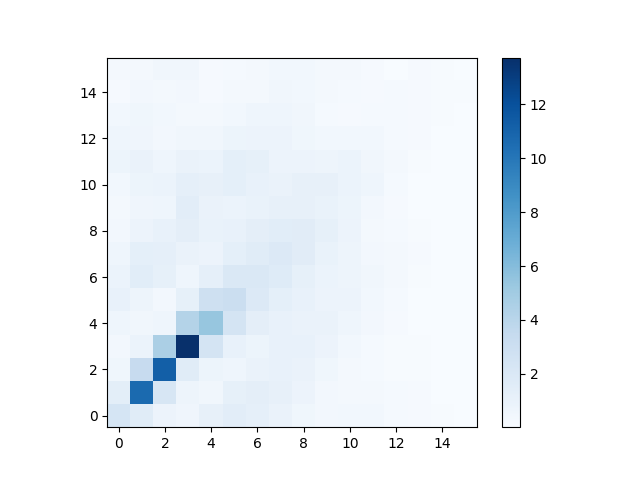

In [8]:
%matplotlib widget
plt.clf()
age_rate_contact_matrix = np.loadtxt('ageinteractionmat.csv')
plt.imshow(age_rate_contact_matrix, cmap ='Blues', origin='lower')
plt.colorbar()
plt.show()

In [9]:
numpatches = len(age_stratification) * len(districts)
print(numpatches)
numagegroups = len(age_stratification)
network_matrix_patch = np.zeros((numpatches, numpatches))
for i in range(len(districts)):
    network_matrix_patch[i*numagegroups:(i+1)*numagegroups, i*numagegroups:(i+1)*numagegroups] = age_rate_contact_matrix

512


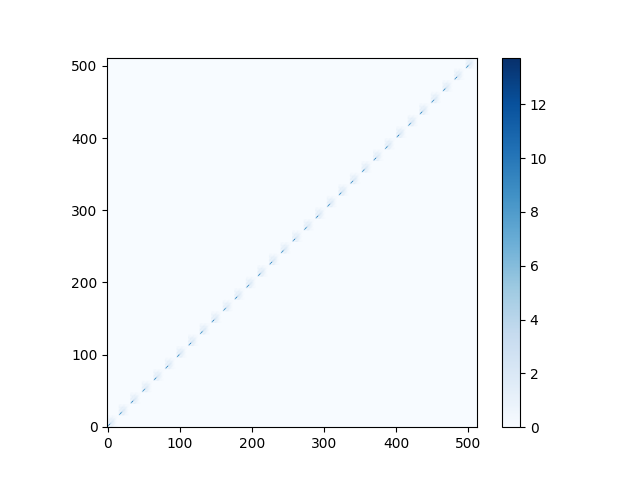

In [10]:
%matplotlib widget
plt.clf()
plt.imshow(network_matrix_patch, cmap ='Blues', origin='lower')
plt.colorbar()
plt.show()

In [11]:

# transitions = [
#     {"from": "R", "to" : "S", "rate": "np.random.weibull( recovery_shape, 1/recovery_size) if R>=0 else 0"}
#     {"from": "E", "to" : "I", "rate": "alpha * E"}
#     {"from": "I", "to": "R", "rate": "gamma * I"}
# ]

# parameters= {
#     'alpha':1/5.8,
#     'beta':beta,
#     'efficacy':0.66,
#     'gamma':1/5,
#     'vaccination_doses_with_time':None,
#     'days_for_vaccine_effect': 14,
#     'recovery_shape':weibull_shape,
#     'recovery_scale':weibull_scale
#     }
# seirv_compartmental_model = model.CompartmentalModel(
#     compartments= [
#         'S',
#         'E',
#         'I',
#         'R',
#         'V',
#         'dayindex'
#         ],
#     parameters= {
#         'alpha':1/5.8,
#         'beta':beta,
#         'efficacy':0.66,
#         'gamma':1/5,
#         'vaccination_doses_with_time':None,
#         'days_for_vaccine_effect': 14,
#         'recovery_shape':weibull_shape,
#         'recovery_scale':weibull_scale
#         },
#     transitions= transitions
# )

In [21]:
from numpy.typing import NDArray
def patchmodel_seirv_step( 
        patchstate: NDArray,
        beta_patches: NDArray,
        patch_contact_rate_matrix:NDArray,
        gamma:float,
        alpha:float,
        vaccine_efficacy:float,
        num_vaccinated_14_days_prior:int,
        weibull_scale:float,
        weibull_shape:float
        )->NDArray:
    """
    Stepper for the patch model, 
    returns a patch_num X 5 sized array.
    patchstate: NDArray,
    beta_patches: NDArray,
    patch_contact_rate_matrix:NDArray,
    gamma:float,
    alpha:float,
    vaccine_efficacy:float,
    num_vaccinated_14_days_prior:int,
    weibull_scale:float,
    weibull_shape:float,
    num_districts:int

    """
    return_array = np.zeros( patchstate.shape)
    population_patch = patchstate.sum(axis=1)
    assert population_patch.shape[0] == patchstate.shape[0]
    # Exposed contacts
    exposed = patchstate[:, 0]* (patch_contact_rate_matrix @ patchstate[:,2])/population_patch
    # Vaccinated effects
    vaccinated_effected = vaccine_efficacy*num_vaccinated_14_days_prior 
    # Random waning
    waning = weibull_scale*np.random.weibull(weibull_shape, size= patchstate.shape[0])*\
    (1*(patchstate[:,4]>0) )

    infected = alpha*patchstate[:,1] 
    recovered = gamma*patchstate[:, 2]
    return_array[:, 0] = -exposed - vaccinated_effected + waning
    return_array[:, 1] = -infected + exposed
    return_array[:, 1] = infected - recovered
    return_array[:, 3] = recovered - waning
    return_array[:, 4] = vaccinated_effected
    return return_array


def simulate(
        betas_district:NDArray,
        initpatchstates:NDArray,
        patch_contact_rate_matrix:NDArray,
        gamma:float,
        alpha:float,
        vaccine_efficacy:float,
        vaccinations_14_day_prior:NDArray,
        weibull_scale:float,
        weibull_shape:float,
        num_of_days:int
        )->NDArray:
    """
    
    Parameters
    ----------
    - vaccinations: NDArray
        Vaccination array with the number of second vaccine dosage, the vaccine dosage array has the same size as the
        num_of_days, but starts from 14 days before the initial date. 
    """
    ## making a num_of_days x numpatches x 5 shaped array
    patches_states_vs_time = [initpatchstates]
    num_ages_groups = patch_contact_rate_matrix.shape[0]//len(betas_district)
    betas_patches = []
    for i, beta in enumerate(betas_district):
        betas_patches+= [beta]*num_ages_groups
    
    betas_patches = np.array(betas_patches)
    assert len(betas_patches) == patch_contact_rate_matrix.shape[0]
    for day in range(num_of_days-1):
        step = patchmodel_seirv_step(
            patchstate=patches_states_vs_time[-1],
            beta_patches=betas_patches,
            patch_contact_rate_matrix= patch_contact_rate_matrix,
            gamma=gamma,
            alpha=alpha,
            vaccine_efficacy=vaccine_efficacy,
            num_vaccinated_14_days_prior=vaccinations_14_day_prior[day],
            weibull_scale=weibull_scale,
            weibull_shape=weibull_shape
            )
        newstate = step + patches_states_vs_time[-1]
        patches_states_vs_time.append(newstate)
    return np.array(patches_states_vs_time)


    

In [22]:
# betas_district:NDArray,
# initpatchstates:NDArray,
fixed_parameters = {
    'alpha': 1/5.8,
    'gamma': 1/5,
    'patch_contact_rate_matrix':network_matrix_patch,
    'vaccine_efficacy':0.66,
    'weibull_scale':weibull_scale,
    'weibull_shape':weibull_shape,
}


In [24]:
first_wave_num_days = 30
vaccine = [0]*first_wave_num_days
betas_district = [1]*len(districts)
first_wave_vaccinations_14_day_prior = vaccine,
init_patch_first = np.ones((network_matrix_patch.shape[0], 5))
init_patch_first[:,0] = init_patch_first[:,0]*30000
simulated_data= simulate(
    betas_district=betas_district,
    initpatchstates= init_patch_first,
    num_of_days=first_wave_num_days,
    vaccinations_14_day_prior=vaccine,
    **fixed_parameters
)

In [25]:
simulated_data.shape

(30, 512, 5)